In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target          # 단위: $100,000

print(df.shape)                    # (20640, 9)
print(df.describe())

(20640, 9)
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308  

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# 경고 메시지 숨기기
import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1775022025.108754   73473 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775022025.182333   73473 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775022026.888811   73473 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# 1. 데이터 로드 및 전처리
print("데이터 로딩 및 전처리 중...")
data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

데이터 로딩 및 전처리 중...


In [4]:
#비교할 활성화 함수 목록
activation_functions = ['relu', 'sigmoid', 'tanh', 'elu']

# 결과를 저장할 딕셔너리와 리스트
histories = {}
evaluation_results = []

In [5]:
# 모델 생성 함수
def build_and_train_model(activation_name):
    model = Sequential([
        Dense(64, activation=activation_name, input_shape=(X_train_scaled.shape[1],)),
        Dense(32, activation=activation_name),
        Dense(1) # 출력층은 회귀이므로 활성화 함수 없음
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # 조기 종료 (학습 시간 단축 및 과적합 방지)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    print(f"[{activation_name.upper()}] 모델 학습 시작...")
    # 출력물이 너무 길어지지 않게 verbose=0 으로 설정
    history = model.fit(
        X_train_scaled, y_train,
        epochs=100,
        validation_split=0.2,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0 
    )
    
    # 테스트 데이터로 평가
    loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
    
    return history, loss, mae

In [6]:
# 각 활성화 함수별로 모델 학습 및 결과 저장
for act in activation_functions:
    history, loss, mae = build_and_train_model(act)
    histories[act] = history
    evaluation_results.append({
        'Activation': act.upper(),
        'Test MSE (Loss)': loss,
        'Test MAE': mae
    })

I0000 00:00:1775022210.658520   73473 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


[RELU] 모델 학습 시작...


I0000 00:00:1775022212.323834   80337 service.cc:153] XLA service 0x78d6a4030ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775022212.323871   80337 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775022212.338099   80337 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775022212.425536   80337 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775022212.431771   80337 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1264__.9
I0000 00:00:1775022213.331866   80337 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1775022214.156042   80339 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1264

[SIGMOID] 모델 학습 시작...


I0000 00:00:1775022293.076392   80336 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_181735__.9
I0000 00:00:1775022294.925933   80336 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_181735__.9


[TANH] 모델 학습 시작...


I0000 00:00:1775022390.937674   80337 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_394027__.9
I0000 00:00:1775022392.846170   80337 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_394027__.9


[ELU] 모델 학습 시작...


I0000 00:00:1775022473.427154   80336 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_570392__.9
I0000 00:00:1775022475.159933   80336 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_570392__.9


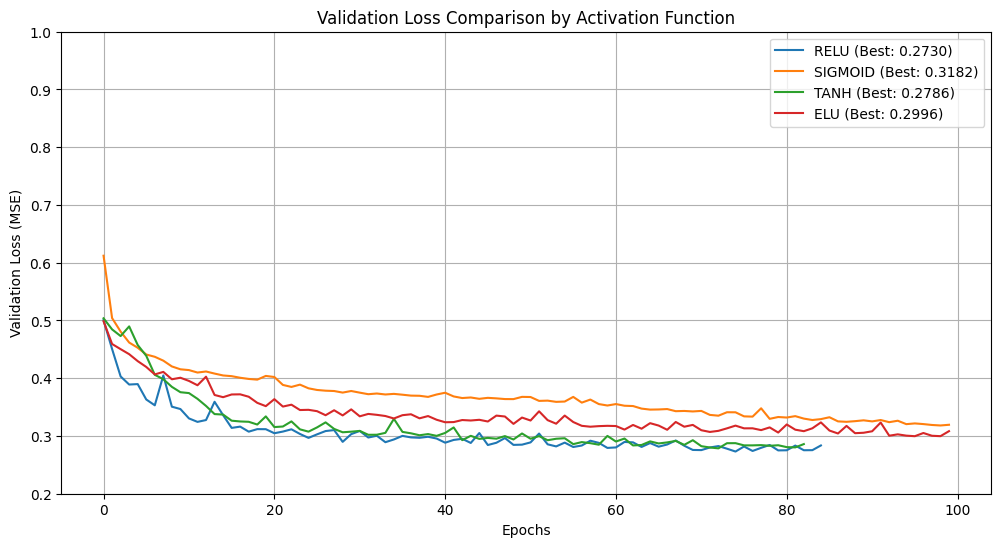


### 최종 평가 결과 요약 (Test Set) ###


,Activation,Test MSE (Loss),Test MAE
0,RELU,0.269123,0.342930
1,TANH,0.272538,0.352872
2,ELU,0.284026,0.362937
3,SIGMOID,0.302114,0.379762


In [7]:
plt.figure(figsize=(12, 6))

for act in activation_functions:
    val_loss = histories[act].history['val_loss']
    plt.plot(val_loss, label=f"{act.upper()} (Best: {min(val_loss):.4f})")

plt.title('Validation Loss Comparison by Activation Function')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss (MSE)')
plt.ylim(0.2, 1.0) # 비교가 잘 되도록 y축 범위 제한
plt.legend()
plt.grid(True)
plt.show()

# 2. 결과 데이터프레임 출력
results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values(by='Test MSE (Loss)').reset_index(drop=True)

print("\n### 최종 평가 결과 요약 (Test Set) ###")
display(results_df) # 주피터 노트북 환경에서는 깔끔한 표로 출력됩니다.

In [9]:
!pip install seaborn

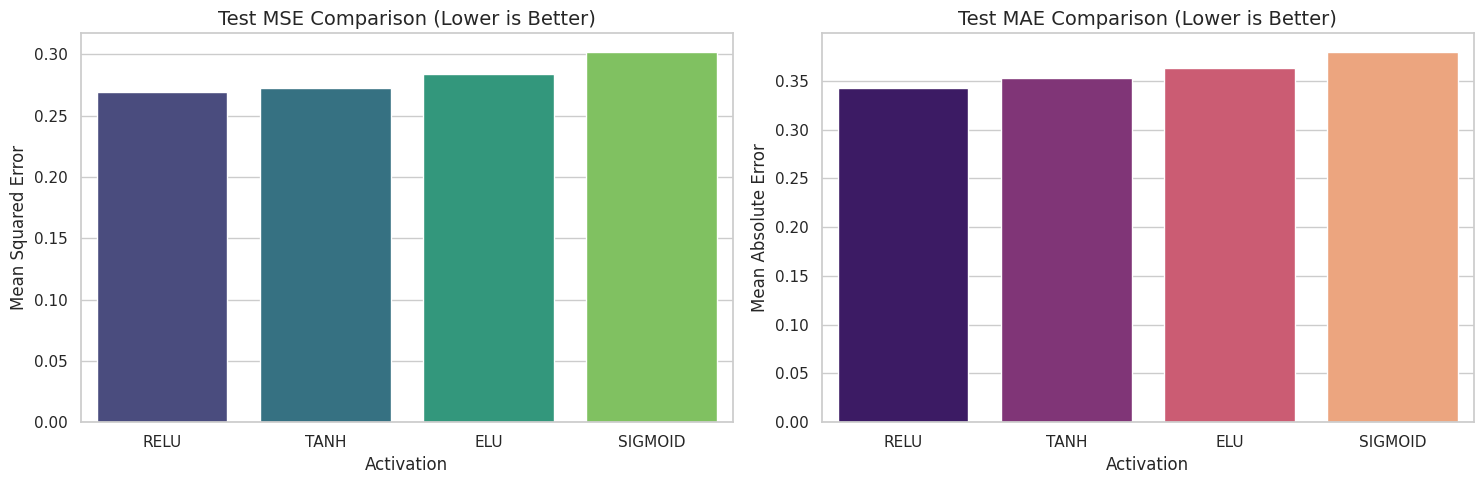

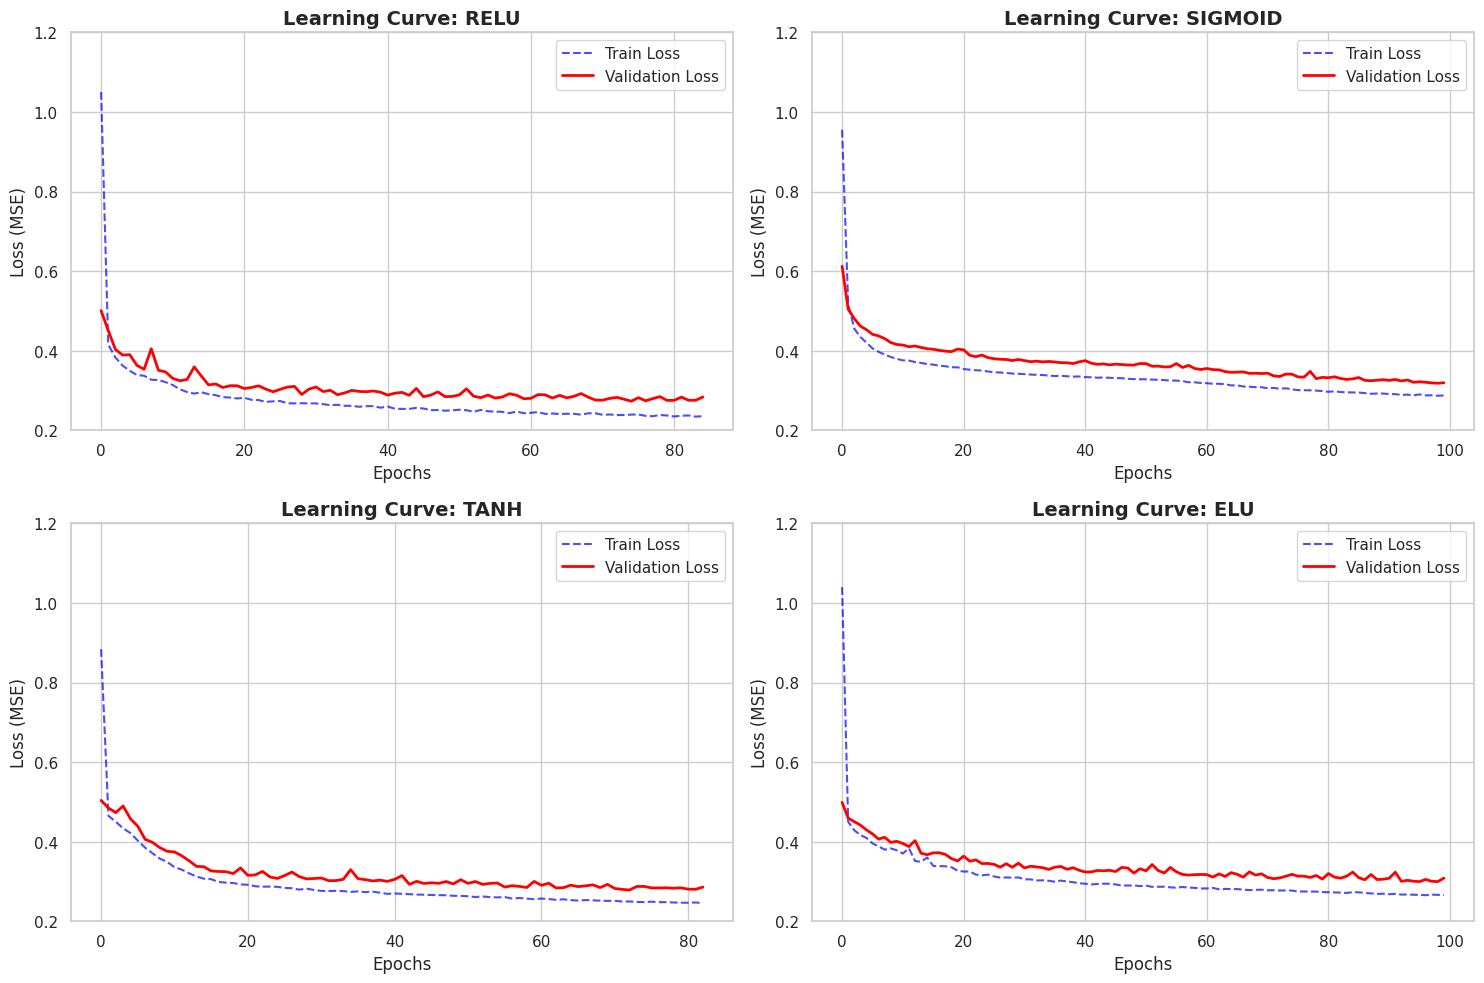

In [10]:
# ==========================================
# 셀 4: 상세 결과 시각화
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")

# 1. 최종 성능(MSE, MAE) 비교 막대 그래프
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MSE 막대 그래프 (낮을수록 좋음)
sns.barplot(x='Activation', y='Test MSE (Loss)', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Test MSE Comparison (Lower is Better)', fontsize=14)
axes[0].set_ylabel('Mean Squared Error')

# MAE 막대 그래프 (낮을수록 좋음)
sns.barplot(x='Activation', y='Test MAE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Test MAE Comparison (Lower is Better)', fontsize=14)
axes[1].set_ylabel('Mean Absolute Error')

plt.tight_layout()
plt.show()

# 2. 각 활성화 함수별 Train vs Validation Loss 개별 학습 곡선 (2x2 서브플롯)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, act in enumerate(activation_functions):
    ax = axes[idx]
    # 앞에서 저장해둔 histories 딕셔너리에서 데이터 추출
    history_dict = histories[act].history
    
    # 훈련 손실과 검증 손실 그리기
    ax.plot(history_dict['loss'], label='Train Loss', linestyle='--', color='blue', alpha=0.7)
    ax.plot(history_dict['val_loss'], label='Validation Loss', linewidth=2, color='red')
    
    ax.set_title(f'Learning Curve: {act.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss (MSE)')
    ax.set_ylim(0.2, 1.2)  # Y축 범위를 통일하여 비교하기 쉽게 설정
    ax.legend()

plt.tight_layout()
plt.show()

# 📊 캘리포니아 주택 가격 예측: DNN 활성화 함수 성능 비교 분석 보고서

## 1. 실험 개요
* **목적:** 다층 퍼셉트론(DNN) 회귀 모델을 구축하여 캘리포니아 주택 가격을 예측하고, 은닉층에 적용된 4가지 주요 활성화 함수(ReLU, Tanh, ELU, Sigmoid)에 따른 모델의 학습 속도 및 최종 예측 성능을 비교 분석한다.
* **데이터셋:** Scikit-learn 제공 캘리포니아 주택 가격 데이터 (총 20,640건, 독립 변수 8개)
* **타겟 변수:** 주택 가격 (단위: 100,000 달러, 최고값이 5.0으로 상한선 제한됨)

## 2. 실험 환경 및 모델 구조
* **데이터 전처리:** * Train / Test 데이터 분할 (8:2 비율)
  * `StandardScaler`를 이용한 입력 변수 표준화(Scaling) 적용
* **모델 아키텍처 (순차 모델):**
  * **입력층 -> 은닉층 1** (노드 64개) -> **은닉층 2** (노드 32개) -> **출력층** (노드 1개, 회귀 예측을 위해 활성화 함수 미사용)
* **학습 설정:**
  * **손실 함수(Loss):** MSE (평균 제곱 오차)
  * **평가 지표(Metrics):** MAE (평균 절대 오차)
  * **최적화 함수(Optimizer):** Adam (기본 학습률)
  * **학습 조건:** 최대 100 Epochs, Batch Size 32, 검증 데이터 기준 Early Stopping 적용 (Patience 10)

## 3. 실험 결과 요약
각 활성화 함수별 테스트 데이터(Test Set)에 대한 최종 평가 결과는 다음과 같다. 

| 순위 | 활성화 함수 (Activation) | Test MSE (Loss) | Test MAE | 오차 환산 금액 |
| :--- | :--- | :--- | :--- | :--- |
| **1** | **ReLU** | 0.269123 | 0.342930 | 약 34,293 달러 |
| **2** | **Tanh** | 0.272538 | 0.352872 | 약 35,287 달러 |
| **3** | **ELU** | 0.284026 | 0.362937 | 약 36,293 달러 |
| **4** | **Sigmoid** | 0.302114 | 0.379762 | 약 37,976 달러 |

## 4. 결과 분석
* **ReLU의 우수성 확인:** 정형 데이터 회귀 문제의 일반적인 경향과 일치하게, **ReLU** 함수가 가장 낮은 오차(MSE 0.269123)를 기록하며 1위를 차지했다. MAE 기준으로 보았을 때, 실제 집값 대비 평균적으로 약 34,293 달러의 예측 오차를 보이고 있다. 양수 영역에서 기울기(Gradient)가 죽지 않아 효율적인 파라미터 업데이트가 이루어진 결과로 분석된다.
* **Tanh의 선전:** Tanh가 ELU보다 근소하게 더 나은 성능을 보여준 점이 특징적이다. 입력 데이터를 평균 0, 분산 1로 스케일링했기 때문에, 출력값의 중심이 0으로 맞춰진(Zero-centered) Tanh 함수가 은닉층에서 안정적이고 효율적으로 작동한 것으로 파악된다.
* **Sigmoid의 한계 (기울기 소실):** Sigmoid 함수는 가장 높은 오차를 기록하며 최하위의 성능을 보였다. 층을 통과할 때마다 기울기가 0에 가깝게 작아지는 **기울기 소실(Vanishing Gradient)** 현상으로 인해, 모델이 변수들 간의 복잡한 비선형 패턴을 끝까지 학습하지 못한 것이 주된 원인이다.

## 5. 신경망 성능 향상을 위한 향후 개선 방안
현재의 Base Model에서 예측 오차를 더욱 줄이고 성능을 고도화하기 위해 다음과 같은 4가지 개선 방안을 제안한다.

1. **데이터 엔지니어링 (상한선 이상치 처리):** 타겟 변수인 주택 가격(Price)이 5.0(500,000 달러)에서 인위적으로 잘려있는(Capped) 현상이 존재한다. 이는 모델 학습에 심각한 노이즈로 작용하므로, 해당 데이터 포인트를 제거하고 재학습시켜 성능 변화를 확인해야 한다.
2. **네트워크 구조 확장 (Wider & Deeper):** 현재의 2개 은닉층(64, 32) 구조를 `[128, 64, 32]` 또는 `[256, 128, 64]` 등으로 확장하여 모델이 데이터의 복잡성을 더 잘 파악할 수 있도록 수용력(Capacity)을 늘린다.
3. **과적합 방지 기법 도입:** 네트워크가 깊어짐에 따라 발생할 수 있는 과적합을 방지하기 위해, 각 은닉층 사이에 `Dropout(0.2)` 층을 추가하거나 `BatchNormalization()`을 적용하여 학습의 안정성을 도모한다.
4. **학습률(Learning Rate) 스케줄링:** Adam 옵티마이저의 고정 학습률 대신, 학습이 정체되는 구간에서 자동으로 학습률을 낮춰주는 기법(`ReduceLROnPlateau` 콜백 등)을 적용하여 더 세밀하게 전역 최적점(Global Minimum)을 탐색한다.

▶ 원본 데이터 크기: (20640, 9)
▶ 상한가(5.0) 제거 후 데이터 크기: (19648, 9) (약 1,000개 데이터 제거됨)

🚀 개선된 모델 학습을 시작합니다...


I0000 00:00:1775023852.072783   80340 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_784266__.31
I0000 00:00:1775023852.135146   80340 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775023852.704193   80340 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775023853.159707   80340 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775023853.6425


Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 47: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.

Epoch 54: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.

Epoch 59: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.

Epoch 64: ReduceLROnPlateau reducing learning rate to 0.00015624999650754035.
Epoch 64: early stopping
Restoring model weights from the end of the best epoch: 49.

✅ [개선된 모델 최종 평가 결과]
Test MSE (Loss): 0.2420
Test MAE: 0.3367 ($ 33,670 오차)


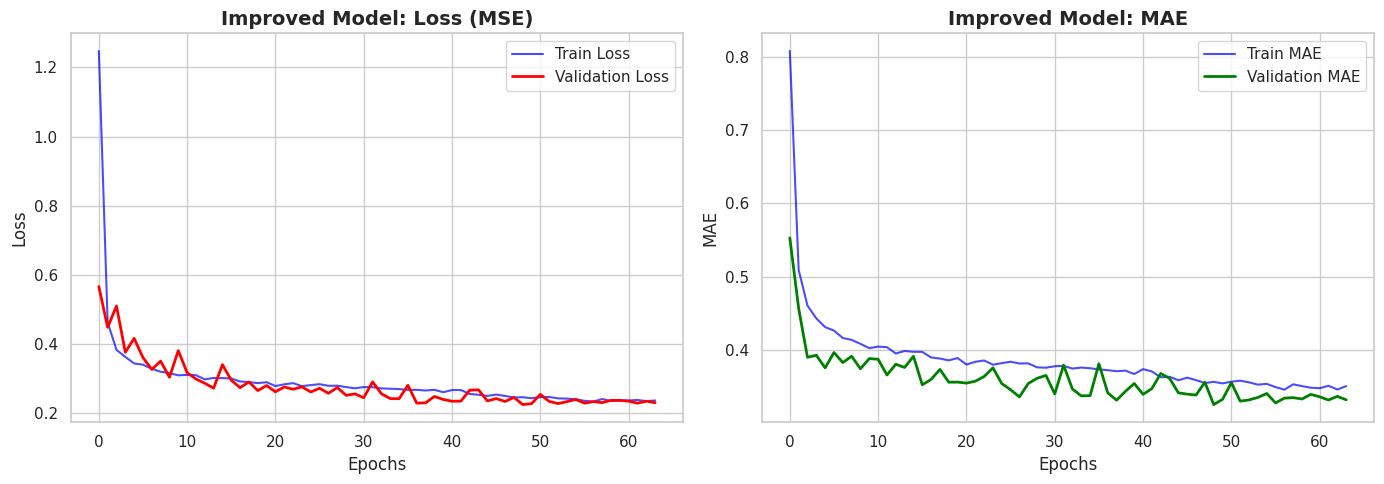

In [11]:
# ==========================================
# [성능 향상 실험] 개선된 DNN 모델 학습 파이프라인
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 경고 메시지 숨기기
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 로드 및 엔지니어링 (★ 가장 중요한 개선점)
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

print(f"▶ 원본 데이터 크기: {df.shape}")

# 상한선(Capped) 5.0 데이터 제거 (노이즈 제거)
df_cleaned = df[df['Price'] < 5.0].copy()
print(f"▶ 상한가(5.0) 제거 후 데이터 크기: {df_cleaned.shape} (약 1,000개 데이터 제거됨)")

X = df_cleaned.drop('Price', axis=1).values
y = df_cleaned['Price'].values

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 2. 개선된 모델 아키텍처 구축 (Wider, Deeper & 정규화)
model = Sequential([
    # 첫 번째 은닉층 (노드 64 -> 128로 증가)
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(), # 배치 정규화 추가 (학습 안정성)
    Dropout(0.3),         # 드롭아웃 추가 (과적합 방지)
    
    # 두 번째 은닉층 (노드 32 -> 64로 증가)
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # 세 번째 은닉층 (★ 층 추가: Deeper)
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # 출력층 (회귀)
    Dense(1)
])


# 3. 콜백 및 옵티마이저 설정 (학습률 스케줄링)
# 학습이 정체되면 학습률을 절반(factor=0.5)으로 줄여 더 세밀하게 탐색
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

# EarlyStopping의 인내심(patience)을 늘려 더 충분히 학습하도록 유도
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

# 초기 학습률을 0.005로 약간 높게 설정 (ReduceLROnPlateau가 깎아나갈 예정)
optimizer = Adam(learning_rate=0.005)

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])


# 4. 모델 학습
print("\n🚀 개선된 모델 학습을 시작합니다...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,           # 최대 에포크 수 증가
    validation_split=0.2,
    batch_size=64,        # 배치 사이즈 증가 (안정적인 기울기 계산)
    callbacks=[early_stop, reduce_lr],
    verbose=0             # 1로 변경하면 에포크마다 진행 상황을 볼 수 있습니다.
)


# 5. 최종 평가
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n✅ [개선된 모델 최종 평가 결과]")
print(f"Test MSE (Loss): {loss:.4f}")
print(f"Test MAE: {mae:.4f} ($ {mae * 100000:,.0f} 오차)")


# 6. 학습 과정 시각화 (Loss & MAE)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(history.history['loss'], label='Train Loss', color='blue', alpha=0.7)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[0].set_title('Improved Model: Loss (MSE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# MAE 그래프
axes[1].plot(history.history['mae'], label='Train MAE', color='blue', alpha=0.7)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='green', linewidth=2)
axes[1].set_title('Improved Model: MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# 📊 캘리포니아 주택 가격 예측: DNN 성능 최적화 최종 보고서

## 1. 실험 개요 및 1차 모델 선정
* 앞선 4가지 활성화 함수 비교 실험 결과, 가장 빠른 수렴 속도와 최저 오차를 기록한 **ReLU**를 최종 신경망의 활성화 함수로 채택하였다.
* 초기 베이스 모델의 한계를 극복하기 위해, 데이터 엔지니어링 및 네트워크 구조 최적화(Tuning)를 거친 '개선된 모델(Optimized Model)'을 구축하여 최종 성능을 평가하였다.

## 2. 성능 개선 적용 사항 (Optimization Strategies)
최종 모델에는 성능 향상과 과적합 방지를 위해 다음 4가지 핵심 전략이 적용되었다.
1. **데이터 전처리 (가장 핵심):** 타겟 변수(Price)의 상한선 캡핑 데이터(5.0 이상 데이터, 약 1,000건)를 이상치 노이즈로 규정하고 제거하여 모델의 패턴 인식력을 높였다.
2. **네트워크 확장 (Wider & Deeper):** 은닉층을 2개에서 3개로 늘리고, 각 층의 노드 수를 확대(128 -> 64 -> 32)하여 데이터의 복잡한 비선형성을 충분히 담아낼 수 있도록 설계했다.
3. **과적합 방지 및 안정화:** 각 은닉층에 `BatchNormalization`과 `Dropout(0.2~0.3)`을 배치하여 깊어진 신경망이 훈련 데이터에만 과도하게 적합되는 현상을 방지했다.
4. **학습률 스케줄링:** `ReduceLROnPlateau` 콜백을 적용해 학습이 정체되는 구간에서 학습률(Learning Rate)을 자동으로 낮춰, 더 세밀하게 최적점을 탐색하도록 유도했다.

## 3. 최종 개선 결과 비교
개선 전(Base Model)과 개선 후(Optimized Model)의 테스트 데이터 최종 평가 결과는 다음과 같다.

| 구분 | Test MSE (Loss) | Test MAE | 오차 환산 금액 |
| :--- | :--- | :--- | :--- |
| **개선 전 (Base ReLU)** | 0.2691 | 0.3429 | 약 34,290 달러 |
| **개선 후 (Optimized)** | **0.2420** | **0.3367** | **약 33,670 달러** |

* **성능 향상 요약:** 개선 전 대비 **MSE가 약 10% 감소**하는 유의미한 성능 향상을 이뤄냈다. 실제 집값 예측 오차(MAE) 기준으로도 평균 약 620 달러가량 더 정밀한 예측이 가능해졌다.

## 4. 결론 및 시사점
* 단순히 딥러닝의 층을 깊게 쌓는 것을 넘어, **도메인 지식을 활용한 데이터 전처리(상한선 노이즈 제거)**가 모델 성능에 얼마나 극적인 영향을 미치는지 확인했다.
* ReLU 계열의 활성화 함수와 배치 정규화(Batch Normalization), 드롭아웃(Dropout)의 조합이 정형 데이터 회귀 분석에서 매우 강력하고 안정적인 파이프라인이 됨을 검증하였다.